In [ ]:
!unzip /content/CSE-CIC-IDS2018.zip -d /content/CSE-CIC-IDS2018


Archive:  /content/CSE-CIC-IDS2018.zip
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Brute Force -XSS.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Brute Force -Web.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DDOS attack-LOIC-UDP.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/SQL Injection.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-Slowloris.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-GoldenEye.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-SlowHTTPTest.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Bot.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DDOS attack-HOIC.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Infilteration.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/FTP-BruteForce.csv  
  inflating: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-Hulk.csv  
  inflating: /content/CSE-CIC-IDS201

In [ ]:
!ls /content/CSE-CIC-IDS2018.zip


ls: cannot access '/content/CSE-CIC-IDS2018.zip': No such file or directory


Found CSV files: 14
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Brute Force -XSS.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Infilteration.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Brute Force -Web.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-GoldenEye.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-SlowHTTPTest.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/SSH-Bruteforce.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/FTP-BruteForce.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/Bot.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DDOS attack-LOIC-UDP.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/SQL Injection.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DoS attacks-Hulk.csv
Loading sample from: /content/CSE-CIC-IDS2018/CSE-CIC-IDS2018/DDoS attack

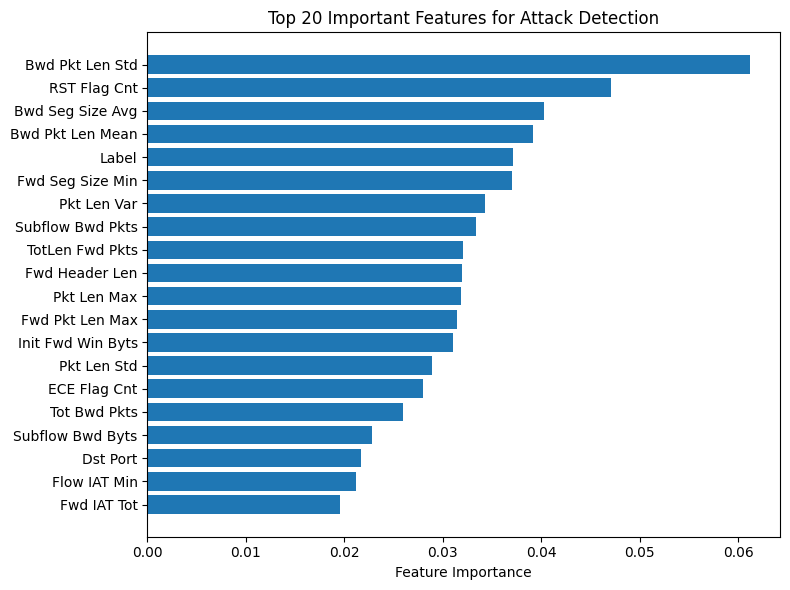

In [ ]:
# =========================================================
#   AI-Powered Network Intrusion Detection System (CIC-IDS2018)
# =========================================================

import pandas as pd
import glob
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import numpy as np

# -----------------------------
# 1️⃣  Load & sample data safely
# -----------------------------
path = "/content/CSE-CIC-IDS2018/CSE-CIC-IDS2018"   # your folder path
files = glob.glob(path + "/*.csv")
print("Found CSV files:", len(files))

dfs = []
for file in files:
    print(f"Loading sample from: {file}")
    # Read only 100k rows per file to save RAM; adjust if you have High-RAM
    df_temp = pd.read_csv(file, nrows=100000)
    df_temp['AttackType'] = file.split("/")[-1].replace(".csv", "")
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print("✅ Combined shape:", df.shape)

# -----------------------------
# 2️⃣  Clean dataset
# -----------------------------
print("🧹 Cleaning data...")
df.columns = df.columns.str.strip()
df = df.drop_duplicates().dropna()
print("✅ After cleaning:", df.shape)

# Ensure label column exists
if "Label" not in df.columns:
    print("⚠️ 'Label' column not found, available columns:\n", df.columns[-10:])
else:
    print("✅ Found 'Label' column")

# Normalize labels
df["Label"] = df["Label"].apply(lambda x: "BENIGN" if str(x).strip().upper() == "BENIGN" else "ATTACK")

# -----------------------------
# 3️⃣  Encode categorical data
# -----------------------------
print("🔤 Encoding categorical features...")
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "Label" in categorical_cols:
    categorical_cols.remove("Label")

encoder = LabelEncoder()
for col in categorical_cols:
    try:
        df[col] = encoder.fit_transform(df[col])
    except Exception as e:
        print(f"Skipping column {col} due to error:", e)

# -----------------------------
# 4️⃣  Prepare features & labels
# -----------------------------
X = df.drop(columns=["Label"])
y = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("✅ Data ready. Train:", X_train.shape, "Test:", X_test.shape)

# -----------------------------
# 5️⃣  Train model
# -----------------------------
print("🤖 Training Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# -----------------------------
# 6️⃣  Evaluate model
# -----------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n📊 Model Performance:")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 7️⃣  Save model & scaler
# -----------------------------
joblib.dump(model, "cic_ids2018_model.joblib")
joblib.dump(scaler, "cic_ids2018_preprocess.joblib")
print("💾 Saved: cic_ids2018_model.joblib, cic_ids2018_preprocess.joblib")

# -----------------------------
# 8️⃣  (Optional) Feature importance
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # top 20 features

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), np.array(df.columns[:-1])[indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Important Features for Attack Detection')
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
files.download("cic_ids2018_model.joblib")
files.download("cic_ids2018_preprocess.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>